# Churn Prediction Analysis

This notebook predicts customer churn using multiple classification models:
1. **Logistic Regression** - Baseline with interpretable coefficients
2. **Random Forest** - Feature importance
3. **Gradient Boosting** - Best performance with SHAP explainability

Also creates a **CLV-Churn Integration Matrix** for prioritized actions.

**Input:** `data/customers_with_clv.csv`  
**Output:** `data/customers_final.csv`

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
import shap
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Load data with CLV columns
df = pd.read_csv('data/customers_with_clv.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nCLV columns present: {[col for col in df.columns if 'clv' in col.lower()]}")

Dataset shape: (5000, 54)

CLV columns present: ['clv_simple', 'clv_rfm_weighted', 'clv_proxy', 'clv_predicted', 'clv_tier']


In [3]:
df.head()

,age,gender,income,education,marital_status,household_size,region,urban_rural,total_purchases_12m,total_spend_12m,...,base_lifespan,customer_lifespan_years,purchase_frequency_annual,clv_simple,clv_rfm_weighted,clv_proxy,clv_predicted,clv_tier,age_group,income_quartile
0,49,Male,60701,Bachelor,Married,2,Southwest,Urban,13,576.94,...,2.0,2.20,13,1269.2680,1946.210933,1172.565898,1198.551749,Silver,46-55,Q1 (Low)
1,39,Male,37033,High School,Married,4,Southwest,Suburban,14,741.65,...,2.0,2.50,14,1854.3000,2842.991667,1425.523884,1412.292309,Silver,36-45,Q1 (Low)
2,51,Male,63185,Master,Widowed,1,Southeast,Suburban,25,2045.20,...,3.5,3.85,25,7874.2125,15223.105333,4520.878927,4533.551498,Diamond,46-55,Q2
3,64,Male,104063,Bachelor,Married,4,Midwest,Suburban,10,889.58,...,2.0,1.70,10,1512.3200,2218.019467,1561.073427,1589.421251,Silver,55+,Q4 (High)
4,38,Male,83414,Bachelor,Married,1,Northeast,Suburban,22,2071.67,...,3.5,3.50,22,7251.0900,14018.300333,4547.812068,4529.590286,Diamond,36-45,Q3


## 2. Churn Label Creation

Since we don't have explicit churn data, we create a **multi-signal churn risk score** based on:
- Recency (days since last purchase)
- Frequency (purchase count)
- Engagement (digital activity)
- Loyalty status
- Email engagement

In [4]:
# Create churn risk score (0-1 range)
df['churn_risk_score'] = (
    # Recency component (0-0.4): higher days since purchase = higher churn risk
    0.4 * np.clip(df['days_since_last_purchase'] / 90, 0, 1) +
    
    # Frequency component (0-0.2): lower purchases = higher churn risk
    0.2 * (1 - np.clip(df['total_purchases_12m'] / 30, 0, 1)) +
    
    # Engagement component (0-0.2): lower engagement = higher churn risk
    0.2 * (1 - df['engagement_score']) +
    
    # Loyalty component (0-0.1): non-members have higher churn risk
    0.1 * (1 - df['loyalty_program_member']) +
    
    # Email engagement component (0-0.1): low email open rate = higher churn risk
    0.1 * (1 - np.clip(df['email_open_rate'] / 0.5, 0, 1))
)

print("Churn Risk Score Distribution:")
print(df['churn_risk_score'].describe())

Churn Risk Score Distribution:
count    5000.000000
mean        0.479481
std         0.143329
min         0.124461
25%         0.367657
50%         0.482052
75%         0.574922
max         0.908889
Name: churn_risk_score, dtype: float64


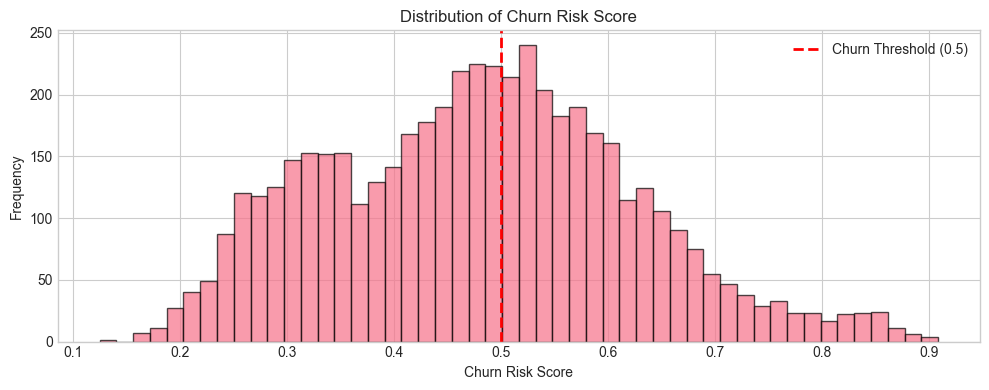

In [5]:
# Visualize churn risk score distribution
plt.figure(figsize=(10, 4))
plt.hist(df['churn_risk_score'], bins=50, edgecolor='black', alpha=0.7)
plt.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Churn Threshold (0.5)')
plt.xlabel('Churn Risk Score')
plt.ylabel('Frequency')
plt.title('Distribution of Churn Risk Score')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# Create binary churn label
CHURN_THRESHOLD = 0.5
df['is_churned'] = (df['churn_risk_score'] > CHURN_THRESHOLD).astype(int)

churn_rate = df['is_churned'].mean()
print(f"Churn Threshold: {CHURN_THRESHOLD}")
print(f"Churn Rate: {churn_rate:.1%}")
print(f"\nChurn Distribution:")
print(df['is_churned'].value_counts())

Churn Threshold: 0.5
Churn Rate: 44.8%

Churn Distribution:
is_churned
0    2758
1    2242
Name: count, dtype: int64


In [7]:
# Analyze churned vs non-churned customers
churn_comparison = df.groupby('is_churned').agg({
    'days_since_last_purchase': 'mean',
    'total_purchases_12m': 'mean',
    'total_spend_12m': 'mean',
    'engagement_score': 'mean',
    'loyalty_program_member': 'mean',
    'clv_predicted': 'mean'
}).round(2)

churn_comparison.index = ['Not Churned', 'Churned']
print("Churned vs Non-Churned Comparison:")
print(churn_comparison.T)

Churned vs Non-Churned Comparison:
                          Not Churned  Churned
days_since_last_purchase        20.88    45.10
total_purchases_12m             19.25    10.89
total_spend_12m               1400.87   739.10
engagement_score                 0.36     0.32
loyalty_program_member           0.59     0.01
clv_predicted                 3011.33  1320.64


## 3. Churn Prediction Models

### 3.1 Feature Preparation

In [8]:
# Features for churn prediction
churn_features = [
    # Demographics
    'age', 'income', 'household_size',
    
    # Purchase behavior
    'total_purchases_12m', 'total_spend_12m', 'avg_order_value',
    'days_since_last_purchase', 'product_categories_purchased',
    'returns_rate', 'discount_usage_rate', 'loyalty_program_member',
    
    # Digital engagement
    'email_open_rate', 'email_click_rate', 'website_visits_30d',
    'avg_session_duration', 'mobile_app_usage', 'social_media_engagement',
    'push_notification_enabled', 'sms_opt_in',
    
    # Derived features
    'engagement_score', 'R_Score', 'F_Score', 'M_Score'
]

X = df[churn_features].copy()
y = df['is_churned'].copy()

print(f"Features: {len(churn_features)}")
print(f"Target distribution: {y.value_counts().to_dict()}")

Features: 23
Target distribution: {0: 2758, 1: 2242}


In [9]:
# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTrain churn rate: {y_train.mean():.1%}")
print(f"Test churn rate: {y_test.mean():.1%}")

Training set: 4000 samples
Test set: 1000 samples

Train churn rate: 44.9%
Test churn rate: 44.8%


In [10]:
# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 3.2 Model Training

In [11]:
# Initialize models with class_weight='balanced' to handle imbalance
models = {
    'Logistic Regression': LogisticRegression(
        random_state=RANDOM_STATE, 
        max_iter=1000, 
        class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, 
        max_depth=10,
        random_state=RANDOM_STATE, 
        class_weight='balanced',
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, 
        max_depth=5,
        learning_rate=0.1,
        random_state=RANDOM_STATE
    )
}

# Store results
results = {}
trained_models = {}

In [12]:
# Train and evaluate each model
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print('='*50)
    
    # Use scaled data for Logistic Regression, unscaled for tree-based
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_prob)
    }
    
    results[name] = metrics
    trained_models[name] = model
    
    print(f"Accuracy:  {metrics['Accuracy']:.4f}")
    print(f"Precision: {metrics['Precision']:.4f}")
    print(f"Recall:    {metrics['Recall']:.4f}")
    print(f"F1 Score:  {metrics['F1']:.4f}")
    print(f"AUC-ROC:   {metrics['AUC-ROC']:.4f}")


Training: Logistic Regression


Accuracy:  0.9770
Precision: 0.9670
Recall:    0.9821
F1 Score:  0.9745
AUC-ROC:   0.9985

Training: Random Forest


Accuracy:  0.9680
Precision: 0.9727
Recall:    0.9554
F1 Score:  0.9640
AUC-ROC:   0.9968

Training: Gradient Boosting


Accuracy:  0.9830
Precision: 0.9865
Recall:    0.9754
F1 Score:  0.9809
AUC-ROC:   0.9986


In [13]:
# Compare models
results_df = pd.DataFrame(results).T
print("\nModel Comparison:")
print(results_df.round(4))


Model Comparison:
                     Accuracy  Precision  Recall      F1  AUC-ROC
Logistic Regression     0.977     0.9670  0.9821  0.9745   0.9985
Random Forest           0.968     0.9727  0.9554  0.9640   0.9968
Gradient Boosting       0.983     0.9865  0.9754  0.9809   0.9986


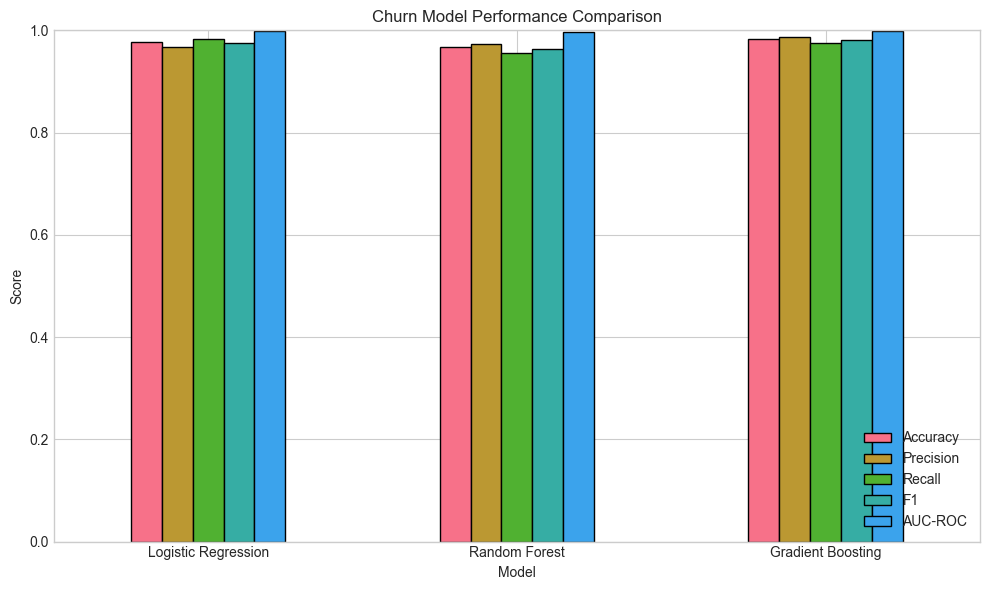

In [14]:
# Visualize model comparison
fig, ax = plt.subplots(figsize=(10, 6))
results_df.plot(kind='bar', ax=ax, edgecolor='black')
ax.set_title('Churn Model Performance Comparison')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.3 ROC and Precision-Recall Curves

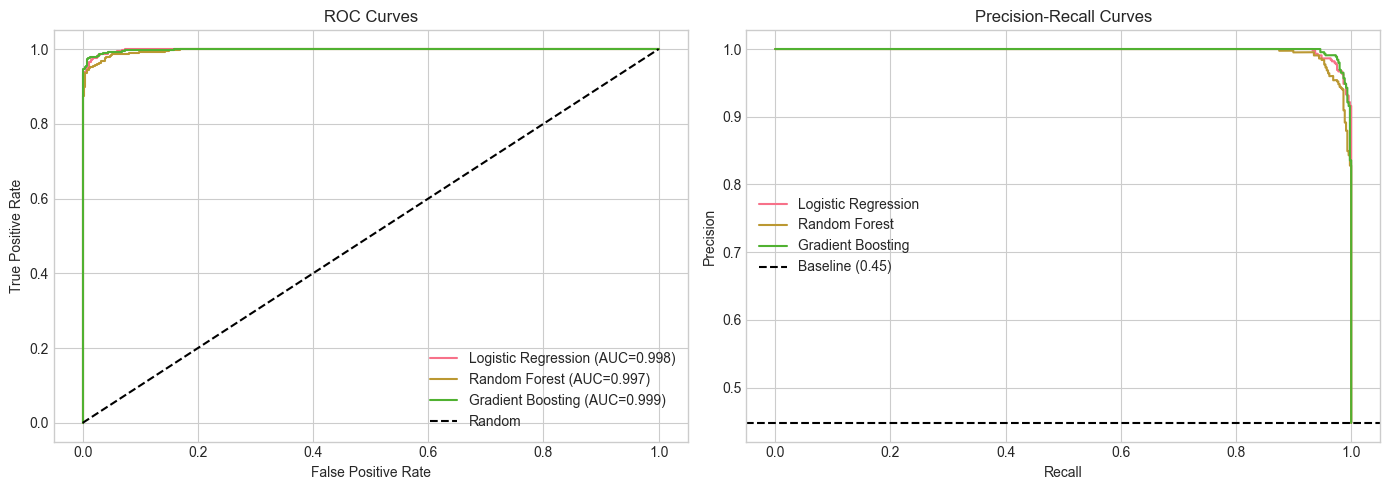

In [15]:
# Plot ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
for name, model in trained_models.items():
    if name == 'Logistic Regression':
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend()

# Precision-Recall Curve
for name, model in trained_models.items():
    if name == 'Logistic Regression':
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.predict_proba(X_test)[:, 1]
    
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    axes[1].plot(recall, precision, label=name)

axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', label=f'Baseline ({y_test.mean():.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.4 Confusion Matrix (Best Model)

Best Model: Gradient Boosting


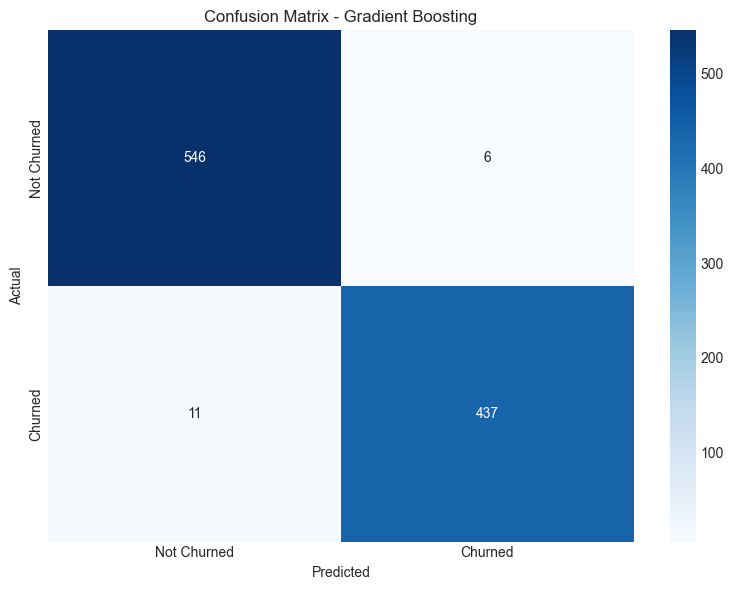


Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.98      0.99      0.98       552
     Churned       0.99      0.98      0.98       448

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



In [16]:
# Best model is Gradient Boosting (highest AUC typically)
best_model_name = max(results, key=lambda x: results[x]['AUC-ROC'])
best_model = trained_models[best_model_name]
print(f"Best Model: {best_model_name}")

# Get predictions
if best_model_name == 'Logistic Regression':
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Not Churned', 'Churned']))

## 4. Churn Probability & Segmentation

In [17]:
# Use Gradient Boosting for final predictions (typically best)
gb_model = trained_models['Gradient Boosting']
df['churn_probability'] = gb_model.predict_proba(X)[:, 1]

print("Churn Probability Distribution:")
print(df['churn_probability'].describe())

Churn Probability Distribution:
count    5000.000000
mean        0.447977
std         0.486314
min         0.000092
25%         0.000499
50%         0.029896
75%         0.999049
max         0.999859
Name: churn_probability, dtype: float64


In [18]:
# Create churn risk segments
df['churn_risk_segment'] = pd.cut(
    df['churn_probability'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['Very Low Risk', 'Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk']
)

print("Churn Risk Segment Distribution:")
print(df['churn_risk_segment'].value_counts().sort_index())

Churn Risk Segment Distribution:
churn_risk_segment
Very Low Risk    2736
Low Risk           19
Medium Risk        16
High Risk          16
Critical Risk    2213
Name: count, dtype: int64


In [19]:
# Analyze by churn risk segment
churn_segment_analysis = df.groupby('churn_risk_segment').agg({
    'churn_probability': ['count', 'mean'],
    'clv_predicted': 'mean',
    'total_spend_12m': 'mean',
    'days_since_last_purchase': 'mean',
    'engagement_score': 'mean'
}).round(2)

churn_segment_analysis.columns = ['Count', 'Avg Churn Prob', 'Avg CLV', 'Avg Spend', 'Avg Days Since', 'Avg Engagement']
print("\nChurn Risk Segment Analysis:")
print(churn_segment_analysis)


Churn Risk Segment Analysis:
                    Count  Avg Churn Prob  Avg CLV  Avg Spend  Avg Days Since  \
churn_risk_segment                                                              
Very Low Risk        2736            0.01  3020.55    1404.21           20.84   
Low Risk               19            0.29  1779.58     907.41           26.74   
Medium Risk            16            0.50  2351.16    1240.21           28.94   
High Risk              16            0.70  1869.39     978.95           26.31   
Critical Risk        2213            0.99  1310.70     734.76           45.32   

                    Avg Engagement  
churn_risk_segment                  
Very Low Risk                 0.36  
Low Risk                      0.32  
Medium Risk                   0.35  
High Risk                     0.33  
Critical Risk                 0.32  


## 5. SHAP Explainability (Gradient Boosting)

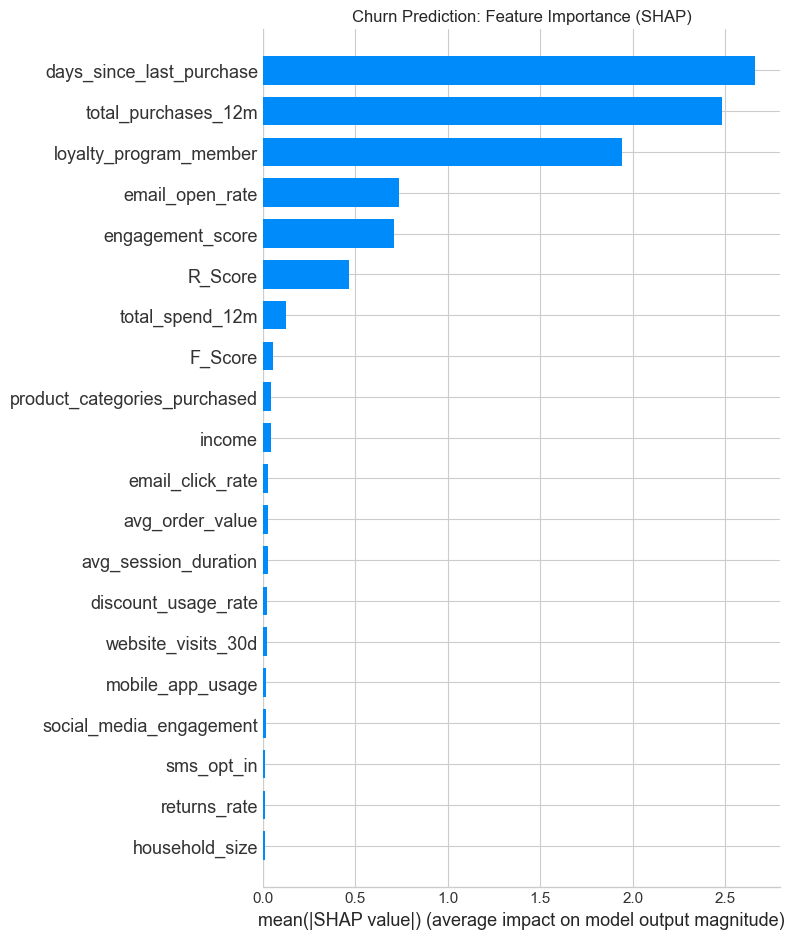

In [20]:
# SHAP analysis
explainer = shap.TreeExplainer(gb_model)
shap_values = explainer.shap_values(X)

# Feature importance bar plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X, plot_type='bar', show=False)
plt.title('Churn Prediction: Feature Importance (SHAP)')
plt.tight_layout()
plt.show()

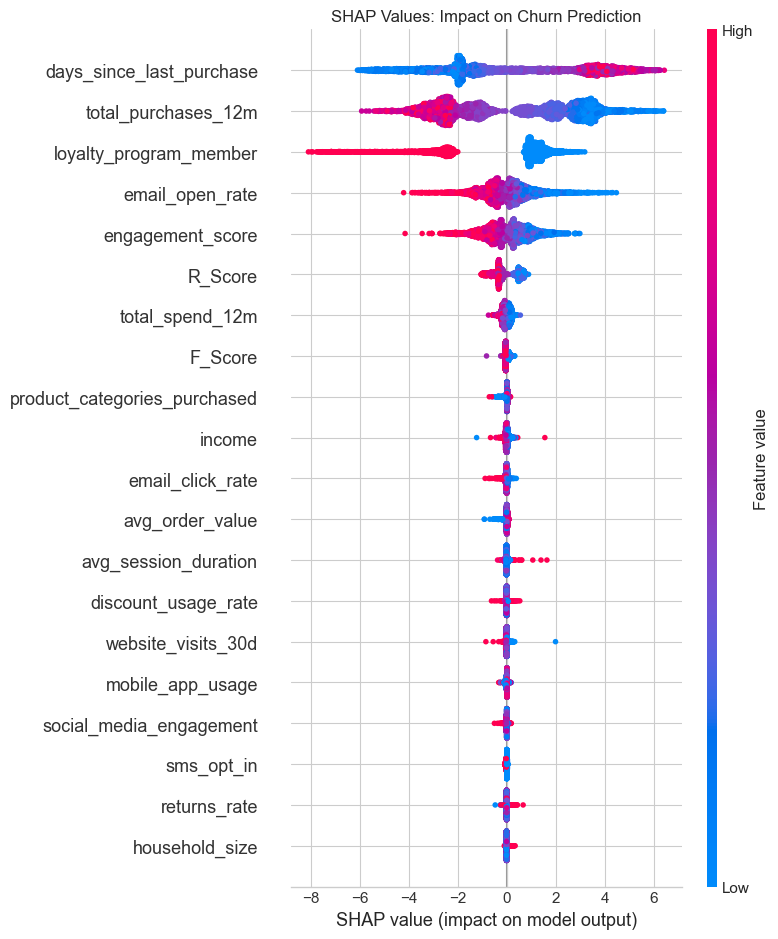

In [21]:
# Detailed SHAP summary
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X, show=False)
plt.title('SHAP Values: Impact on Churn Prediction')
plt.tight_layout()
plt.show()

## 6. CLV-Churn Integration Matrix

In [22]:
# Create CLV-Churn matrix
clv_churn_matrix = pd.crosstab(
    df['clv_tier'], 
    df['churn_risk_segment'],
    margins=True
)

print("CLV Tier vs Churn Risk Matrix (Customer Count):")
print(clv_churn_matrix)

CLV Tier vs Churn Risk Matrix (Customer Count):
churn_risk_segment  Very Low Risk  Low Risk  Medium Risk  High Risk  \
clv_tier                                                              
Bronze                        108         3            1          1   
Diamond                       967         1            3          0   
Gold                          578         6            8          8   
Platinum                      799         3            2          3   
Silver                        284         6            2          4   
All                          2736        19           16         16   

churn_risk_segment  Critical Risk   All  
clv_tier                                 
Bronze                        887  1000  
Diamond                        29  1000  
Gold                          400  1000  
Platinum                      193  1000  
Silver                        704  1000  
All                          2213  5000  


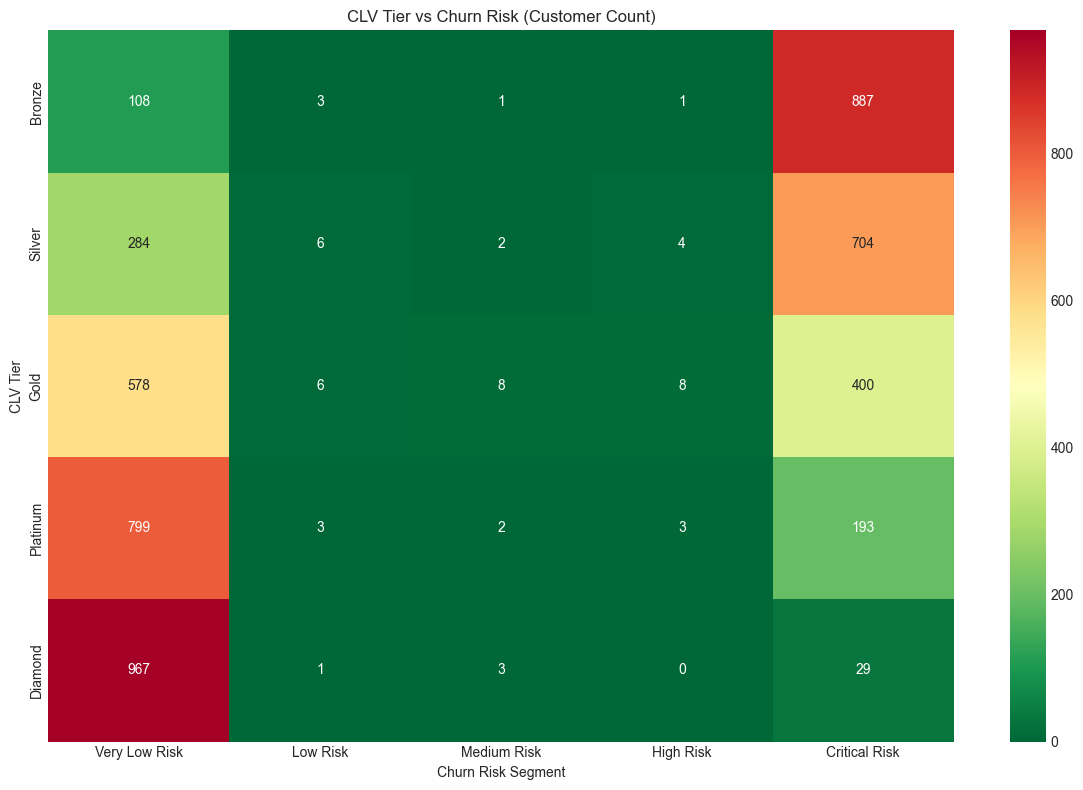

In [23]:
# Heatmap of CLV vs Churn
clv_order = ['Bronze', 'Silver', 'Gold', 'Platinum', 'Diamond']
churn_order = ['Very Low Risk', 'Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk']

matrix_data = pd.crosstab(df['clv_tier'], df['churn_risk_segment'])
matrix_data = matrix_data.reindex(index=clv_order, columns=churn_order)

plt.figure(figsize=(12, 8))
sns.heatmap(matrix_data, annot=True, fmt='d', cmap='RdYlGn_r')
plt.title('CLV Tier vs Churn Risk (Customer Count)')
plt.xlabel('Churn Risk Segment')
plt.ylabel('CLV Tier')
plt.tight_layout()
plt.show()

In [24]:
# Define priority actions based on CLV and Churn
def clv_churn_action(row):
    clv = row['clv_tier']
    churn = row['churn_risk_segment']
    
    # Priority 1: High CLV + High Churn Risk = URGENT
    if clv in ['Diamond', 'Platinum'] and churn in ['High Risk', 'Critical Risk']:
        return '1. URGENT: VIP Win-Back'
    
    # Priority 2: High CLV + Low Churn = Retain & Upsell
    if clv in ['Diamond', 'Platinum'] and churn in ['Very Low Risk', 'Low Risk']:
        return '2. VIP Retain & Upsell'
    
    # Priority 3: High CLV + Medium Churn = Proactive Retention
    if clv in ['Diamond', 'Platinum'] and churn == 'Medium Risk':
        return '3. VIP Proactive Retention'
    
    # Priority 4: Medium CLV + High Churn = Re-engagement
    if clv in ['Gold', 'Silver'] and churn in ['High Risk', 'Critical Risk']:
        return '4. Re-engagement Campaign'
    
    # Priority 5: Medium CLV + Low Churn = Growth Opportunity
    if clv in ['Gold', 'Silver'] and churn in ['Very Low Risk', 'Low Risk']:
        return '5. Growth Opportunity'
    
    # Priority 6: Medium CLV + Medium Churn = Standard Nurture
    if clv in ['Gold', 'Silver'] and churn == 'Medium Risk':
        return '6. Standard Nurture'
    
    # Priority 7: Low CLV + High Churn = Low Priority
    if clv == 'Bronze' and churn in ['High Risk', 'Critical Risk']:
        return '7. Low Priority - Monitor'
    
    # Priority 8: Low CLV + Low/Medium Churn = Acquisition Focus
    return '8. Acquisition Focus'

df['clv_churn_action'] = df.apply(clv_churn_action, axis=1)

print("CLV-Churn Action Distribution:")
print(df['clv_churn_action'].value_counts().sort_index())

CLV-Churn Action Distribution:
clv_churn_action
1. URGENT: VIP Win-Back        225
2. VIP Retain & Upsell        1770
3. VIP Proactive Retention       5
4. Re-engagement Campaign     1116
5. Growth Opportunity          874
6. Standard Nurture             10
7. Low Priority - Monitor      888
8. Acquisition Focus           112
Name: count, dtype: int64


In [25]:
# Analyze CLV-Churn actions
action_analysis = df.groupby('clv_churn_action').agg({
    'clv_predicted': ['count', 'mean', 'sum'],
    'churn_probability': 'mean',
    'total_spend_12m': 'mean'
}).round(2)

action_analysis.columns = ['Count', 'Avg CLV', 'Total CLV', 'Avg Churn Prob', 'Avg Spend']
action_analysis = action_analysis.sort_index()

print("\nCLV-Churn Action Analysis:")
print(action_analysis)


CLV-Churn Action Analysis:
                            Count  Avg CLV   Total CLV  Avg Churn Prob  \
clv_churn_action                                                         
1. URGENT: VIP Win-Back       225  2816.25   633655.96            0.97   
2. VIP Retain & Upsell       1770  3728.27  6599043.44            0.00   
3. VIP Proactive Retention      5  3356.95    16784.77            0.52   
4. Re-engagement Campaign    1116  1580.91  1764297.67            0.99   
5. Growth Opportunity         874  1835.74  1604436.10            0.02   
6. Standard Nurture            10  2000.95    20009.49            0.49   
7. Low Priority - Monitor     888   599.70   532529.16            1.00   
8. Acquisition Focus          112   851.50    95368.07            0.04   

                            Avg Spend  
clv_churn_action                       
1. URGENT: VIP Win-Back       1487.70  
2. VIP Retain & Upsell        1729.44  
3. VIP Proactive Retention    1766.40  
4. Re-engagement Campaign      

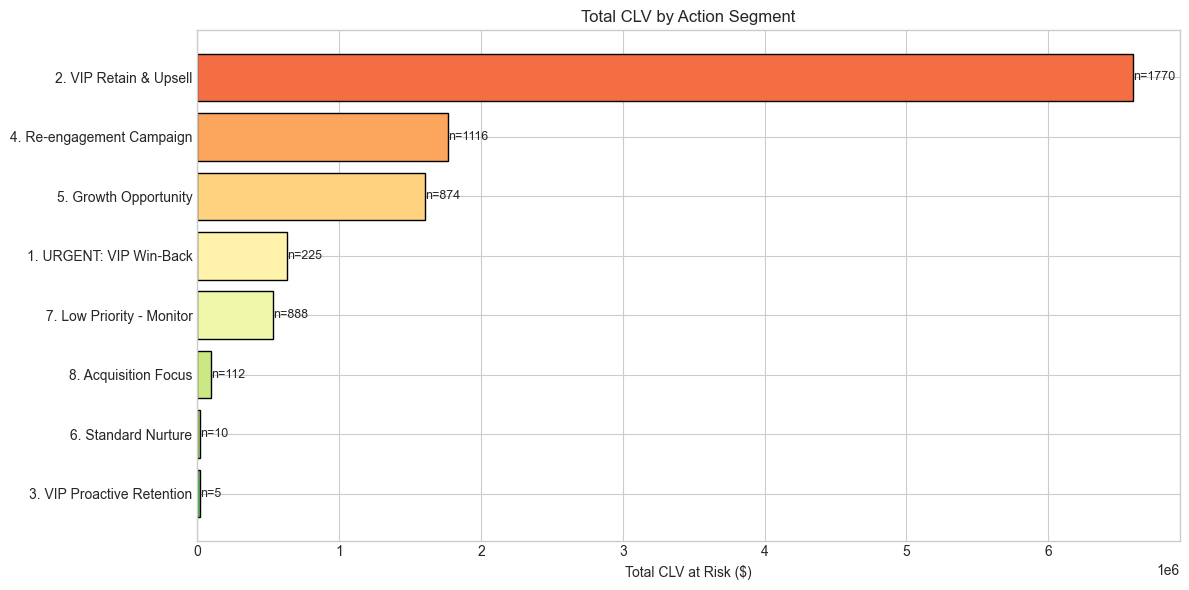

In [26]:
# Visualize: CLV at Risk by Action
plt.figure(figsize=(12, 6))
action_sorted = action_analysis.sort_values('Total CLV', ascending=True)
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(action_sorted)))

plt.barh(range(len(action_sorted)), action_sorted['Total CLV'], color=colors, edgecolor='black')
plt.yticks(range(len(action_sorted)), action_sorted.index)
plt.xlabel('Total CLV at Risk ($)')
plt.title('Total CLV by Action Segment')

# Add count labels
for i, (idx, row) in enumerate(action_sorted.iterrows()):
    plt.text(row['Total CLV'] + 1000, i, f"n={row['Count']:.0f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 7. CLV vs Churn Scatter Plot (High-Value At-Risk)

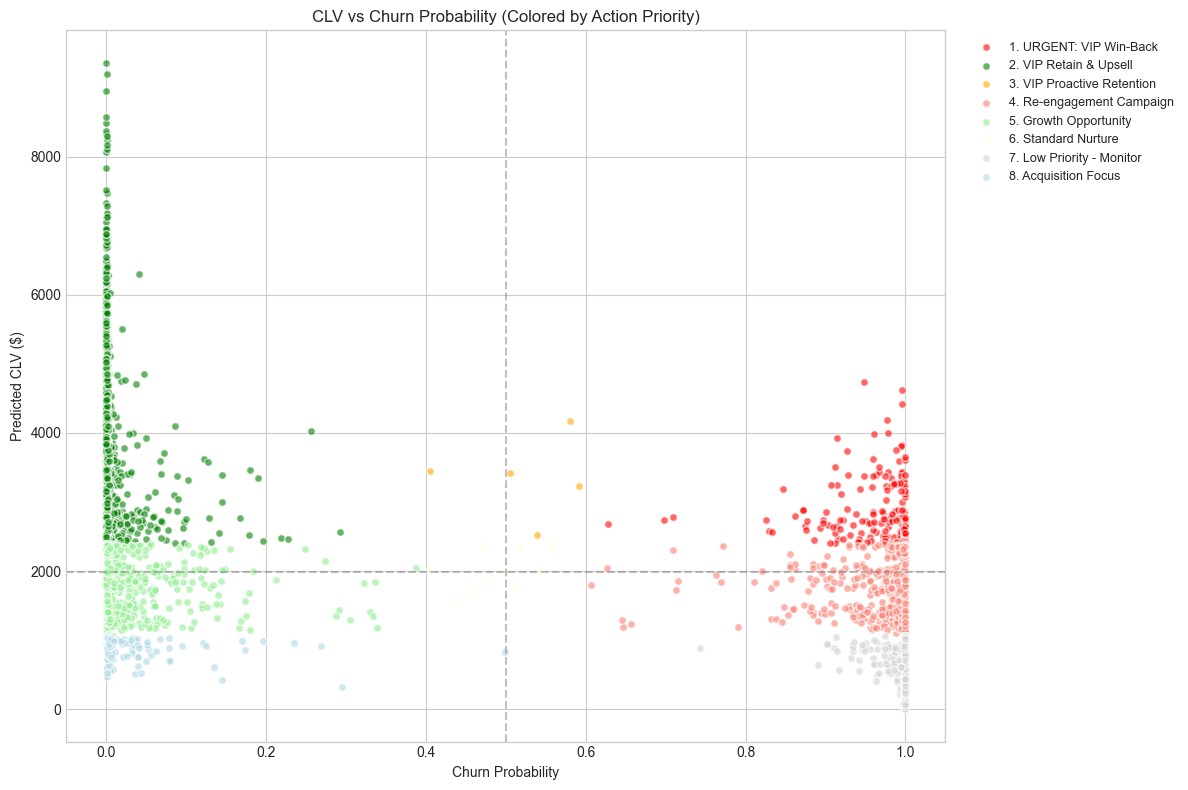

In [27]:
# Scatter plot: CLV vs Churn Probability
plt.figure(figsize=(12, 8))

# Color by action priority
action_colors = {
    '1. URGENT: VIP Win-Back': 'red',
    '2. VIP Retain & Upsell': 'green',
    '3. VIP Proactive Retention': 'orange',
    '4. Re-engagement Campaign': 'salmon',
    '5. Growth Opportunity': 'lightgreen',
    '6. Standard Nurture': 'lightyellow',
    '7. Low Priority - Monitor': 'lightgray',
    '8. Acquisition Focus': 'lightblue'
}

for action, color in action_colors.items():
    mask = df['clv_churn_action'] == action
    plt.scatter(
        df.loc[mask, 'churn_probability'],
        df.loc[mask, 'clv_predicted'],
        c=color, label=action, alpha=0.6, s=30, edgecolor='white'
    )

plt.xlabel('Churn Probability')
plt.ylabel('Predicted CLV ($)')
plt.title('CLV vs Churn Probability (Colored by Action Priority)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

# Add quadrant lines
plt.axhline(y=df['clv_predicted'].median(), color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [28]:
# Identify high-value at-risk customers (URGENT segment)
urgent_customers = df[df['clv_churn_action'] == '1. URGENT: VIP Win-Back']

print(f"\nURGENT: VIP Win-Back Customers")
print(f"="*50)
print(f"Count: {len(urgent_customers)}")
print(f"Total CLV at Risk: ${urgent_customers['clv_predicted'].sum():,.0f}")
print(f"Avg CLV: ${urgent_customers['clv_predicted'].mean():,.0f}")
print(f"Avg Churn Probability: {urgent_customers['churn_probability'].mean():.1%}")
print(f"\nCharacteristics:")
print(f"  Avg Days Since Purchase: {urgent_customers['days_since_last_purchase'].mean():.0f}")
print(f"  Avg Engagement Score: {urgent_customers['engagement_score'].mean():.2f}")
print(f"  Loyalty Member %: {urgent_customers['loyalty_program_member'].mean():.1%}")


URGENT: VIP Win-Back Customers
Count: 225
Total CLV at Risk: $633,656
Avg CLV: $2,816
Avg Churn Probability: 96.9%

Characteristics:
  Avg Days Since Purchase: 34
  Avg Engagement Score: 0.30
  Loyalty Member %: 0.4%


## 8. Summary & Export

In [29]:
# Summary
print("=" * 60)
print("CHURN PREDICTION SUMMARY")
print("=" * 60)
print(f"\nTotal Customers: {len(df):,}")
print(f"Churn Rate (threshold={CHURN_THRESHOLD}): {df['is_churned'].mean():.1%}")
print(f"\nBest Model: {best_model_name}")
print(f"  AUC-ROC: {results[best_model_name]['AUC-ROC']:.4f}")
print(f"  F1 Score: {results[best_model_name]['F1']:.4f}")
print(f"\nChurn Risk Distribution:")
print(df['churn_risk_segment'].value_counts().sort_index())
print(f"\nCLV-Churn Action Distribution:")
print(df['clv_churn_action'].value_counts().sort_index())

CHURN PREDICTION SUMMARY

Total Customers: 5,000
Churn Rate (threshold=0.5): 44.8%

Best Model: Gradient Boosting
  AUC-ROC: 0.9986
  F1 Score: 0.9809

Churn Risk Distribution:
churn_risk_segment
Very Low Risk    2736
Low Risk           19
Medium Risk        16
High Risk          16
Critical Risk    2213
Name: count, dtype: int64

CLV-Churn Action Distribution:
clv_churn_action
1. URGENT: VIP Win-Back        225
2. VIP Retain & Upsell        1770
3. VIP Proactive Retention       5
4. Re-engagement Campaign     1116
5. Growth Opportunity          874
6. Standard Nurture             10
7. Low Priority - Monitor      888
8. Acquisition Focus           112
Name: count, dtype: int64


In [30]:
# New columns added
new_columns = [
    'churn_risk_score', 'is_churned', 'churn_probability', 
    'churn_risk_segment', 'clv_churn_action'
]

print(f"\nNew columns added: {len(new_columns)}")
print(new_columns)


New columns added: 5
['churn_risk_score', 'is_churned', 'churn_probability', 'churn_risk_segment', 'clv_churn_action']


In [31]:
# Export final dataset
df.to_csv('data/customers_final.csv', index=False)
print(f"\nExported to: data/customers_final.csv")
print(f"Total columns: {len(df.columns)}")
print(f"Total rows: {len(df)}")


Exported to: data/customers_final.csv
Total columns: 59
Total rows: 5000


In [32]:
# Preview churn-related columns
print("\nFinal Dataset Preview (Churn columns):")
df[['churn_risk_score', 'is_churned', 'churn_probability', 'churn_risk_segment', 'clv_churn_action']].head(10)


Final Dataset Preview (Churn columns):


,churn_risk_score,is_churned,churn_probability,churn_risk_segment,clv_churn_action
0,0.466368,0,0.006683,Very Low Risk,5. Growth Opportunity
1,0.498216,0,0.329622,Low Risk,5. Growth Opportunity
2,0.346723,0,0.000561,Very Low Risk,2. VIP Retain & Upsell
3,0.565705,1,0.997966,Critical Risk,4. Re-engagement Campaign
4,0.375085,0,0.000624,Very Low Risk,2. VIP Retain & Upsell
5,0.502522,1,0.901866,Critical Risk,7. Low Priority - Monitor
6,0.448200,0,0.008361,Very Low Risk,2. VIP Retain & Upsell
7,0.515875,1,0.950546,Critical Risk,1. URGENT: VIP Win-Back
8,0.449107,0,0.006612,Very Low Risk,5. Growth Opportunity
9,0.357550,0,0.000216,Very Low Risk,5. Growth Opportunity
